In [2]:
from pathlib import Path
from itertools import product
from glob import glob

import cartopy.crs as ccrs
import iris
from IPython.display import HTML, clear_output
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.ndimage as ndimage
import scipy.stats
import xarray as xr
import xesmf as xe

from mcs_prime import mcs_prime_config_util as cu

In [3]:
datadir = cu.PATHS['datadir']
simdir = datadir / 'UM_sims'

EXPTS = {
    'ctrl': 'u-di727',    
    'vanillaMCSP': 'u-di728',    
    'stochMCSP': 'u-dg135',
}
nens = 10

In [4]:
imerg_path = '/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_output/imerg_processed/N216grid/2020-07-01_04:00:00-2020-07-11_03:00:00/3B-HHR.MS.MRG.3IMERG.2020-07-01_04:00:00-2020-07-11_03:00:00.hourly.V07B.nc'
imerg = xr.load_dataarray(imerg_path)

In [5]:
expt_pflux = {}
for expt, suite in EXPTS.items():
    pflux_path = simdir / f'{suite}/processed/{expt}/engla_pa.precip.nc'
    pflux = xr.load_dataarray(pflux_path)
    pflux.values *= 3600 
    pflux.attrs['units'] = 'mm h-1'
    expt_pflux[expt] = pflux


In [6]:
def compare_imerg_pflux_times(imerg, pflux):
    # IMERG has an array of times with items: cftime.DatetimeJulian
    # You can convert to DatetimeIndex as follows:
    imerg_time = xr.CFTimeIndex(imerg.time.values).to_datetimeindex()
    pflux_time = pd.DatetimeIndex(pflux.time)
    return (imerg_time == pflux_time).all()

for expt in EXPTS:
    assert compare_imerg_pflux_times(imerg, expt_pflux[expt]), f'IMERG-pflux times do not match for {expt}'

/home/users/mmuetz/miniconda3/envs/mcs_prime_env/lib/python3.10/site-packages/xarray/coding/times.py:351: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  sample = dates.ravel()[0]
/tmp/ipykernel_651/2649704582.py:4: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  imerg_time = xr.CFTimeIndex(imerg.time.values).to_datetimeindex()


In [7]:
pflux

<xarray.DataArray 'precipitation_flux' (ens_mem: 10, time: 240, latitude: 324,
                                        longitude: 432)>
array([[[[5.70086058e-08, 5.74511994e-08, 5.85264708e-08, ...,
          5.68275098e-08, 5.60472415e-08, 5.63795197e-08],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [7.21303046e-01, 7.26718545e-01, 7.34093964e-01, ...,
          7.07209826e-01, 7.14155972e-01, 7.16285586e-01],
         [1.00384855e+00, 1.02276850e+00, 1.04259682e+00, ...,
          9.68939006e-01, 9.79902506e-01, 9.94887888e-01],
         [7.78948843e-01, 7.75864601e-01, 7.75398076e-01, ...,
          7.81451881e-01, 7.82793224e-01, 7.82975435e-01]],

        [[5.49123236e-08, 5.43240404e-08, 5.23717496e-08, ...,
          5.80393476e-08, 5.65898510e-08, 5.49389405e-08],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          3.53207439e-02, 3.51383872e-02, 3.56202051e-02],
         [1.65125638e-01, 1.74480468e-01, 2.09647432e-01, ...,
          1.39187798e-01, 1.44335702e-01, 1.43901274e-01],
         [4.11710054e-01, 4.26549584e-01, 4.36830729e-01, ...,
          3.87872964e-01, 4.03528064e-01, 4.13347960e-01]],

        [[2.32850880e-06, 2.23825032e-06, 2.17700472e-06, ...,
          2.37576569e-06, 2.42896135e-06, 2.37770382e-06],
         [6.34760954e-06, 6.37983703e-06, 6.42638861e-06, ...,
          6.39921973e-06, 6.35886045e-06, 6.33799255e-06],
         [1.88241120e-05, 1.86567904e-05, 1.84769888e-05, ...,
          1.92688331e-05, 1.91367963e-05, 1.89846287e-05],
         ...,
         [4.03301343e-02, 4.97783720e-02, 5.13772815e-02, ...,
          2.83665899e-02, 2.94690337e-02, 3.64750177e-02],
         [1.42593116e-01, 1.54211700e-01, 1.69939160e-01, ...,
          1.42703623e-01, 1.40671104e-01, 1.27983242e-01],
         [5.65261066e-01, 5.74740529e-01, 5.92100561e-01, ...,
          5.41974545e-01, 5.64260185e-01, 5.54793000e-01]]]],
      dtype=float32)
Coordinates:
  * latitude   (latitude) float32 -89.72 -89.17 -88.61 ... 88.61 89.17 89.72
  * longitude  (longitude) float32 0.4167 1.25 2.083 2.917 ... 357.9 358.7 359.6
  * time       (time) datetime64[ns] 2020-07-01T04:00:00 ... 2020-07-11T03:00:00
  * ens_mem    (ens_mem) int64 0 1 2 3 4 5 6 7 8 9
Attributes:
    standard_name:        precipitation_flux
    units:                mm h-1
    um_stash_source:      m01s05i216
    grid_mapping:         latitude_longitude
    UM simulation:        u-dg135
    MCS:PRIME expt:       stochMCSP
    created by:           /home/users/mmuetz/projects/mcs_prime/ctrl/stoch_tr...
    calling file source:  import numpy as np\nimport pandas as pd\nimport xar...
    project repository:   https://github.com/markmuetz/MCS_PRIME
    remake version:       ['0', '7', '0', '0', 'beta']
    remake repository:    https://github.com/markmuetz/remake
    task:                 <N216_sims_process.N216ExtractCombinePrecip object ...
    task doc:             Extract and combine precipitation at all times and ...
    created on:           2024-09-03 14:50:54.092847
    nodename:             host649.jc.rl.ac.uk
    hostname:             jasmin
    output path:          /gws/nopw/j04/mcs_prime/mmuetz/data/UM_sims/u-dg135...
    contact:              mark.muetzelfeldt@reading.ac.uk
    coordinates:          forecast_period_0 forecast_reference_time_0

(0.6579648546479244, 5.018959017996994e-31)

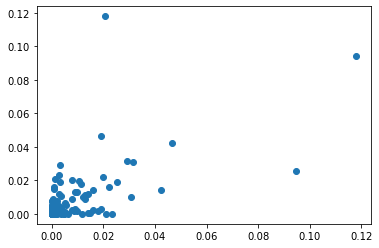

In [6]:
v = pflux[0, :, 162, 0].values
plt.scatter(v[:-1], v[1:])
scipy.stats.pearsonr(v[:-1], v[1:])

In [7]:
pflux0 = pflux.sel(ens_mem=0)

(0.0, 7.5)

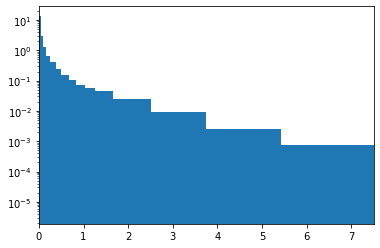

In [19]:
bins = np.array([0.1, 1, 2, 4, 6, 9, 12, 16, 20, 25, 30, 40, 60, 90, 130, 180, 10000]) / 24
plt.hist(pflux0.values.flatten(), bins=bins, log=True, density=True)
plt.xlim((0, 180 / 24))

In [20]:
d = np.digitize(pflux0.values, bins=bins)
d.shape

(240, 324, 432)

In [21]:
probs = np.zeros((len(bins), len(bins)))
for p in zip(d[:-1].flatten(), d[1:].flatten()):
    probs[p] += 1

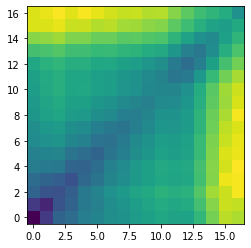

In [22]:
plt.imshow(probs, origin='lower', norm=mcolors.LogNorm(), cmap='viridis_r')

In [26]:
thresh = np.array([0.005, 10, 50, 100]) / 24
d2 = np.digitize(pflux0.values, thresh)

In [27]:
d2.max()

4

In [28]:
pflux0sum = pflux0.sum(dim='time')

/tmp/ipykernel_536/618034042.py:6: RuntimeWarning: invalid value encountered in true_divide
  pdata = (pflux0 * (d2 == i)).sum(dim='time').values / pflux0sum.values
/tmp/ipykernel_536/618034042.py:6: RuntimeWarning: invalid value encountered in true_divide
  pdata = (pflux0 * (d2 == i)).sum(dim='time').values / pflux0sum.values
/tmp/ipykernel_536/618034042.py:6: RuntimeWarning: invalid value encountered in true_divide
  pdata = (pflux0 * (d2 == i)).sum(dim='time').values / pflux0sum.values
/tmp/ipykernel_536/618034042.py:6: RuntimeWarning: invalid value encountered in true_divide
  pdata = (pflux0 * (d2 == i)).sum(dim='time').values / pflux0sum.values
/tmp/ipykernel_536/618034042.py:6: RuntimeWarning: invalid value encountered in true_divide
  pdata = (pflux0 * (d2 == i)).sum(dim='time').values / pflux0sum.values


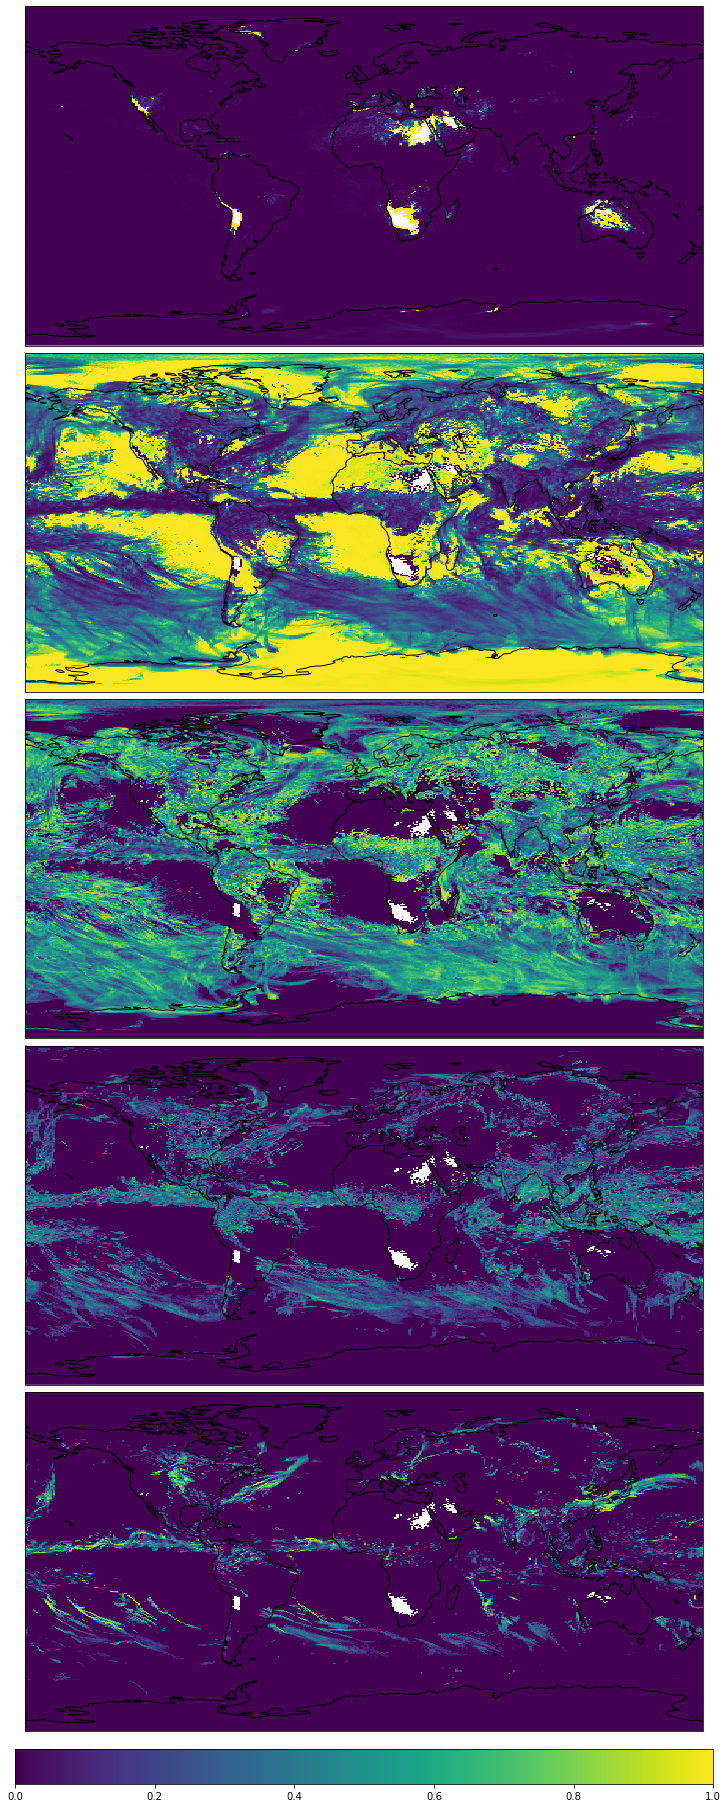

In [34]:
fig, axes = plt.subplots(5, 1, subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
fig.set_size_inches(10, 25)
for i in range(5):
    ax = axes[i]
    ax.coastlines()
    pdata = (pflux0 * (d2 == i)).sum(dim='time').values / pflux0sum.values
    im = ax.pcolormesh(pflux0.longitude, pflux0.latitude, pdata, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, orientation='horizontal')
    

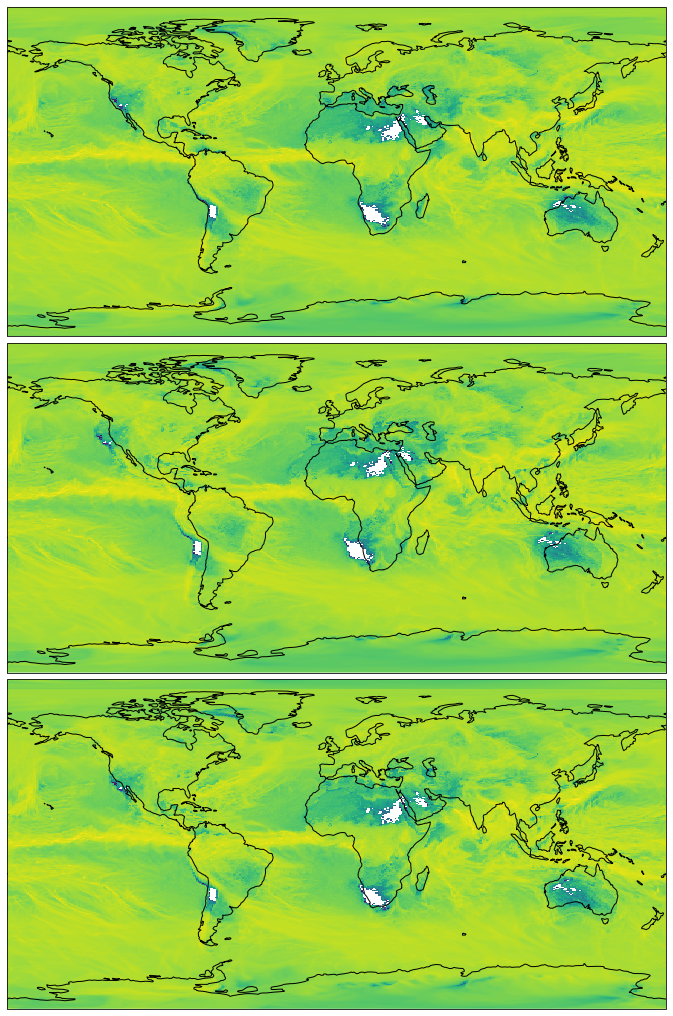

In [39]:
fig, axes = plt.subplots(3, 1, subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
fig.set_size_inches(10, 14)
axes[0].pcolormesh(pflux0.longitude, pflux0.latitude, pflux0.mean(dim='time'), norm=mcolors.LogNorm())
axes[0].coastlines()

axes[1].pcolormesh(pflux0.longitude, pflux0.latitude, np.roll(pflux0.mean(dim='time'), -10, axis=1), norm=mcolors.LogNorm())
axes[1].coastlines()

axes[2].pcolormesh(pflux0.longitude, pflux0.latitude, np.roll(pflux0.mean(dim='time'), -10, axis=0), norm=mcolors.LogNorm())
axes[2].coastlines()

In [41]:
pflux0

<xarray.DataArray 'precipitation_flux' (time: 240, latitude: 324, longitude: 432)>
array([[[5.70086058e-08, 5.74511994e-08, 5.85264708e-08, ...,
         5.68275098e-08, 5.60472415e-08, 5.63795197e-08],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [7.21303046e-01, 7.26718545e-01, 7.34093964e-01, ...,
         7.07209826e-01, 7.14155972e-01, 7.16285586e-01],
        [1.00384855e+00, 1.02276850e+00, 1.04259682e+00, ...,
         9.68939006e-01, 9.79902506e-01, 9.94887888e-01],
        [7.78948843e-01, 7.75864601e-01, 7.75398076e-01, ...,
         7.81451881e-01, 7.82793224e-01, 7.82975435e-01]],

       [[5.49123236e-08, 5.43240404e-08, 5.23717496e-08, ...,
         5.80393476e-08, 5.65898510e-08, 5.49389405e-08],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
        [5.77908568e-02, 4.85286005e-02, 5.06621376e-02, ...,
         9.17249024e-02, 9.66567323e-02, 4.82211150e-02],
        [2.45149270e-01, 2.37642258e-01, 2.17410296e-01, ...,
         2.02307388e-01, 2.12807268e-01, 2.44238973e-01],
        [1.41750112e-01, 1.28048763e-01, 1.01556614e-01, ...,
         1.43194199e-01, 1.52073190e-01, 1.55097812e-01]],

       [[1.38032278e-02, 1.37753058e-02, 1.37415361e-02, ...,
         1.38732009e-02, 1.38546266e-02, 1.38306571e-02],
        [1.14184208e-02, 1.12994844e-02, 1.11812893e-02, ...,
         1.17778070e-02, 1.16581153e-02, 1.15366913e-02],
        [3.74149205e-03, 3.61454464e-03, 3.50229559e-03, ...,
         4.19442309e-03, 4.02903603e-03, 3.88026983e-03],
        ...,
        [2.11589783e-01, 1.81720287e-01, 9.57040265e-02, ...,
         2.64834553e-01, 2.40019381e-01, 1.85427964e-01],
        [1.00855276e-01, 1.33291304e-01, 1.75616279e-01, ...,
         1.19787492e-01, 1.20209143e-01, 1.21879973e-01],
        [6.26587048e-02, 2.05692090e-02, 2.51479689e-02, ...,
         7.27913603e-02, 5.73882908e-02, 4.91720662e-02]]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 -89.72 -89.17 -88.61 ... 88.61 89.17 89.72
  * longitude  (longitude) float32 0.4167 1.25 2.083 2.917 ... 357.9 358.7 359.6
  * time       (time) datetime64[ns] 2020-07-01T04:00:00 ... 2020-07-11T03:00:00
    ens_mem    int64 0
Attributes:
    standard_name:        precipitation_flux
    units:                mm h-1
    um_stash_source:      m01s05i216
    grid_mapping:         latitude_longitude
    UM simulation:        u-dg135
    MCS:PRIME expt:       stochMCSP
    created by:           /home/users/mmuetz/projects/mcs_prime/ctrl/stoch_tr...
    calling file source:  import numpy as np\nimport pandas as pd\nimport xar...
    project repository:   https://github.com/markmuetz/MCS_PRIME
    remake version:       ['0', '7', '0', '0', 'beta']
    remake repository:    https://github.com/markmuetz/remake
    task:                 <N216_sims_process.N216ExtractCombinePrecip object ...
    task doc:             Extract and combine precipitation at all times and ...
    created on:           2024-09-03 14:50:54.092847
    nodename:             host649.jc.rl.ac.uk
    hostname:             jasmin
    output path:          /gws/nopw/j04/mcs_prime/mmuetz/data/UM_sims/u-dg135...
    contact:              mark.muetzelfeldt@reading.ac.uk
    coordinates:          forecast_period_0 forecast_reference_time_0

In [42]:
pflux0flat = pflux0.values[:, 3:-3].flatten()
spat_corr = np.zeros((7, 7))
for i, j in product(range(7), range(7)):
    
    print(i, j)
    shift_lon = i - 3
    shift_lat = j - 3
    spat_corr[j, i] = scipy.stats.pearsonr(pflux0flat, np.roll(np.roll(pflux0.values, shift_lon, axis=-1), shift_lat, axis=-2)[:, 3:-3].flatten())[0]

0 0
0 1
0 2
0 3
0 4
0 5
0 6
1 0
1 1
1 2
1 3
1 4
1 5
1 6
2 0
2 1
2 2
2 3
2 4
2 5
2 6
3 0
3 1
3 2
3 3
3 4
3 5
3 6
4 0
4 1
4 2
4 3
4 4
4 5
4 6
5 0
5 1
5 2
5 3
5 4
5 5
5 6
6 0
6 1
6 2
6 3
6 4
6 5
6 6


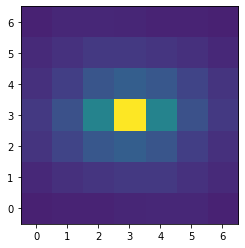

In [43]:
plt.imshow(spat_corr, origin='lower', vmin=0, vmax=1)

In [44]:
import seaborn as sns

<AxesSubplot:>

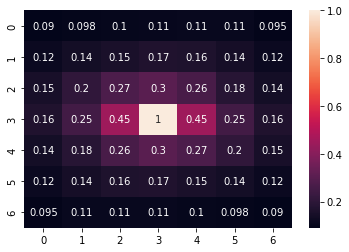

In [45]:
sns.heatmap(spat_corr, annot=True)

In [46]:
spat_corr

array([[0.09036105, 0.09827903, 0.10147754, 0.10812393, 0.11097465,
        0.11031925, 0.09521452],
       [0.11652477, 0.13679355, 0.1536006 , 0.1670547 , 0.16409589,
        0.1416636 , 0.11758023],
       [0.15065325, 0.20415567, 0.27244654, 0.30024276, 0.26410355,
        0.18366913, 0.13745221],
       [0.16499425, 0.24811415, 0.44577229, 1.        , 0.44577229,
        0.24811415, 0.16499425],
       [0.13742882, 0.18364795, 0.2640867 , 0.30022789, 0.27243026,
        0.20413581, 0.15063079],
       [0.11757364, 0.14165975, 0.16409467, 0.16705388, 0.15359835,
        0.13678955, 0.11651869],
       [0.09524759, 0.11035445, 0.11100978, 0.1081585 , 0.10151101,
        0.09831193, 0.09039266]])

In [60]:
a = np.array([[1, 2], [1, 3], [1, 2], [4, 5]])

In [68]:
np.unique(a, axis=0, return_counts=True)

(array([[1, 2],
        [1, 3],
        [4, 5]]),
 array([2, 1, 1]))

In [108]:
%%timeit -n1 -r1
probs = np.zeros((len(bins), len(bins)))
idx, counts = np.unique(np.vstack((d[:-1].flatten(), d[1:].flatten())), axis=1, return_counts=True)
for i, c in zip(idx.T, counts):
    probs[tuple(i)] = c


1min 1s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


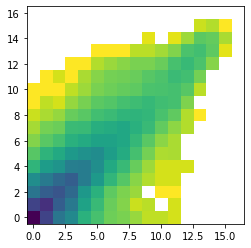

In [101]:
plt.imshow(probs, origin='lower', norm=mcolors.LogNorm(), cmap='viridis_r')

<AxesSubplot:>

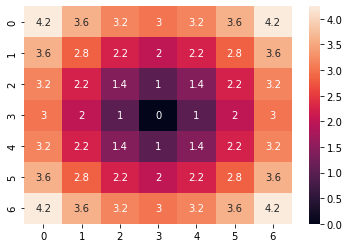

In [47]:
x = np.linspace(-3, 3, 7)
y = np.linspace(-3, 3, 7)
X, Y = np.meshgrid(x, y)
sns.heatmap(np.sqrt(X**2 + Y**2), annot=True)

<AxesSubplot:>

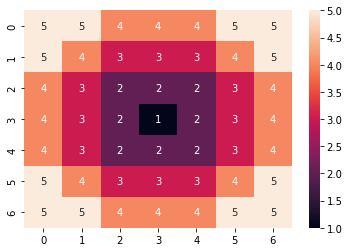

In [48]:
bins = np.array([0, 0.5, 1.5, 2.5, 3.5])
sns.heatmap(np.digitize(np.sqrt(X**2 + Y**2), bins), annot=True)

In [49]:
d = np.digitize(np.sqrt(X**2 + Y**2), bins)
for j in range(1, 6):
    print(j, spat_corr[d == j].mean())

1 1.0
2 0.32063528445876044
3 0.18677791294168958
4 0.13151971530344478
5 0.10472315203225853


In [56]:
pflux0flat = pflux0.values[:, 3:-3].flatten()
spat_temp_corr = np.zeros((5, 7, 7))
for i, j, k in product(range(7), range(7), range(5)):
    
    print(i, j, k)
    shift_lon = i - 3
    shift_lat = j - 3
    shift_time = k
    if k == 0:
        spat_temp_corr[k, j, i] = scipy.stats.pearsonr(pflux0.values[:, 3:-3].flatten(), np.roll(np.roll(pflux0.values, shift_lon, axis=-1), shift_lat, axis=-2)[:, 3:-3].flatten())[0]    
    else:
        spat_temp_corr[k, j, i] = scipy.stats.pearsonr(pflux0.values[:-k, 3:-3].flatten(), np.roll(np.roll(pflux0.values, shift_lon, axis=-1), shift_lat, axis=-2)[k:, 3:-3].flatten())[0]

0 0 0
0 0 1
0 0 2
0 0 3
0 0 4
0 1 0
0 1 1
0 1 2
0 1 3
0 1 4
0 2 0
0 2 1
0 2 2
0 2 3
0 2 4
0 3 0
0 3 1
0 3 2
0 3 3
0 3 4
0 4 0
0 4 1
0 4 2
0 4 3
0 4 4
0 5 0
0 5 1
0 5 2
0 5 3
0 5 4
0 6 0
0 6 1
0 6 2
0 6 3
0 6 4
1 0 0
1 0 1
1 0 2
1 0 3
1 0 4
1 1 0
1 1 1
1 1 2
1 1 3
1 1 4
1 2 0
1 2 1
1 2 2
1 2 3
1 2 4
1 3 0
1 3 1
1 3 2
1 3 3
1 3 4
1 4 0
1 4 1
1 4 2
1 4 3
1 4 4
1 5 0
1 5 1
1 5 2
1 5 3
1 5 4
1 6 0
1 6 1
1 6 2
1 6 3
1 6 4
2 0 0
2 0 1
2 0 2
2 0 3
2 0 4
2 1 0
2 1 1
2 1 2
2 1 3
2 1 4
2 2 0
2 2 1
2 2 2
2 2 3
2 2 4
2 3 0
2 3 1
2 3 2
2 3 3
2 3 4
2 4 0
2 4 1
2 4 2
2 4 3
2 4 4
2 5 0
2 5 1
2 5 2
2 5 3
2 5 4
2 6 0
2 6 1
2 6 2
2 6 3
2 6 4
3 0 0
3 0 1
3 0 2
3 0 3
3 0 4
3 1 0
3 1 1
3 1 2
3 1 3
3 1 4
3 2 0
3 2 1
3 2 2
3 2 3
3 2 4
3 3 0
3 3 1
3 3 2
3 3 3
3 3 4
3 4 0
3 4 1
3 4 2
3 4 3
3 4 4
3 5 0
3 5 1
3 5 2
3 5 3
3 5 4
3 6 0
3 6 1
3 6 2
3 6 3
3 6 4
4 0 0
4 0 1
4 0 2
4 0 3
4 0 4
4 1 0
4 1 1
4 1 2
4 1 3
4 1 4
4 2 0
4 2 1
4 2 2
4 2 3
4 2 4
4 3 0
4 3 1
4 3 2
4 3 3
4 3 4
4 4 0
4 4 1
4 4 2
4 4 3
4 4 4
4 5 0
4 5 

In [62]:
spat_temp_corr2 = np.zeros((5, 4))
for i in range(5):
    for j in range(1, 5):
        spat_temp_corr2[i, j - 1] = spat_temp_corr[i, :, :][d == j].mean()

<AxesSubplot:>

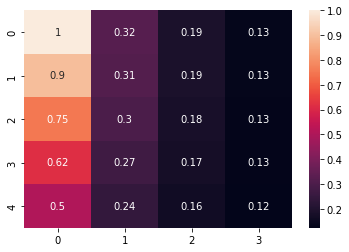

In [63]:
sns.heatmap(spat_temp_corr2, annot=True)

In [20]:
c = np.zeros((324, 432))
p = np.zeros((324, 432))
for j, k in product(range(324), range(432)):
    v = pflux[0, :, j, k].values
    res = scipy.stats.pearsonr(v[:-1], v[1:])
    c[j, k] = res[0]
    p[j, k] = res[1]

In [38]:
res

(0.9025907652403372, 1.022699689859163e-88)

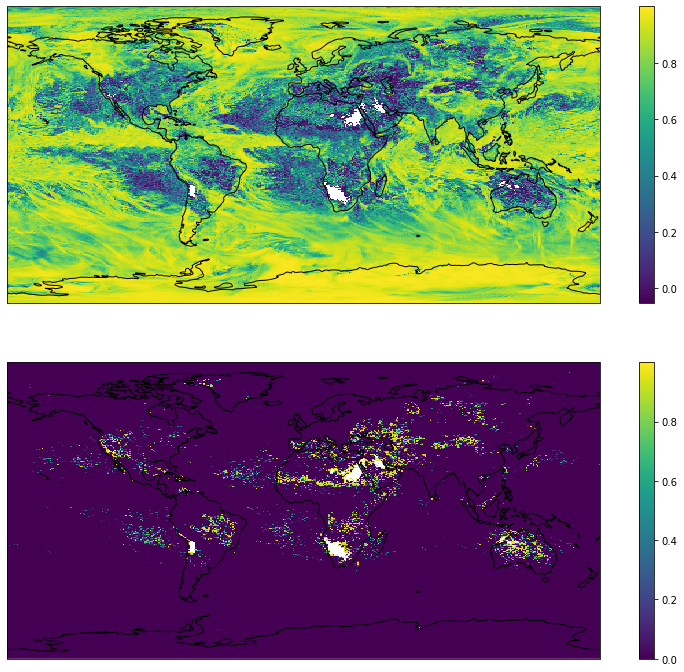

In [30]:
fig, (ax0, ax1) = plt.subplots(2, 1, subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_size_inches((14, 12))
# im = ax0.pcolormesh(pflux.longitude, pflux.latitude, c, vmin=-1, vmax=1, cmap='bwr')
im = ax0.pcolormesh(pflux.longitude, pflux.latitude, c)
ax0.coastlines()
plt.colorbar(im, ax=ax0)

im = ax1.pcolormesh(pflux.longitude, pflux.latitude, p)
ax1.coastlines()
plt.colorbar(im, ax=ax1)

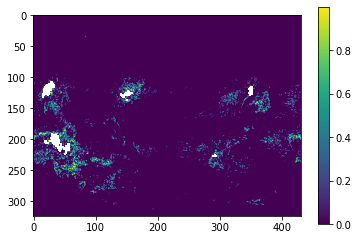

In [24]:
plt.imshow(p)
plt.colorbar()

In [34]:
pflux_autocorr = pflux[:, 0].copy().rename('pflux_autocorr').to_dataset()
pflux_autocorr['pflux_autocorr_pvalue'] = pflux[:, 0].copy().rename('pflux_autocorr_pvalue')


In [37]:
pflux_autocorr.pflux_autocorr.shape

(10, 324, 432)

In [7]:
imerg

<xarray.DataArray (time: 240, latitude: 324, longitude: 432)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.11      , 0.14056149, 0.14056125, ..., 0.        ,
         0.        , 0.        ],
        [0.0999866 , 0.13666438, 0.11833221, ..., 0.19999999,
         0.19999999, 0.19999999],
        [0.10113055, 0.14889447, 0.07223611, ..., 0.13      ,
         0.03609293, 0.13      ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.18146932, 0.3516631 , 0.35166326, ..., 0.18424271,
         0.16      , 0.29999998],
        [0.34666443, 0.36666438, 0.36166778, ..., 0.32500336,
         0.32833904, 0.3316745 ],
        [0.5055861 , 0.6128267 ,        nan, ..., 0.37555498,
         0.39888787, 0.43574366]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.34      , 0.3477754 , 0.34      , ..., 0.3277755 ,
         0.3338877 , 0.34      ],
        [0.2600067 , 0.31333563, 0.31333557, ..., 0.36499664,
         0.31500342, 0.31833893],
        [0.45889443, 0.45889446, 0.21758379, ..., 0.73169583,
         0.64557654, 0.5316856 ]]], dtype=float32)
Coordinates:
  * time       (time) object 2020-07-01 04:00:00 ... 2020-07-11 03:00:00
  * longitude  (longitude) float32 0.4167 1.25 2.083 2.917 ... 357.9 358.7 359.6
  * latitude   (latitude) float32 -89.72 -89.17 -88.61 ... 88.61 89.17 89.72
Attributes:
    regrid_method:        bilinear
    created by:           /home/users/mmuetz/projects/mcs_prime/ctrl/stoch_tr...
    calling file source:  import numpy as np\nimport pandas as pd\nimport xar...
    project repository:   https://github.com/markmuetz/MCS_PRIME
    remake version:       ['0', '6', '3', '0', 'beta']
    remake repository:    https://github.com/markmuetz/remake
    task:                 4f0f96cf80 RegridImergToN216(times_args=(('2020-07-...
    task doc:             Regrid IMERG to the same grid as N216 simulations.\...
    created on:           2024-08-09 10:21:08.923606
    nodename:             host639.jc.rl.ac.uk
    hostname:             jasmin
    output path:          /gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_outpu...
    contact:              mark.muetzelfeldt@reading.ac.uk

In [8]:
imerg_ts = imerg.mean(dim=['latitude', 'longitude'])

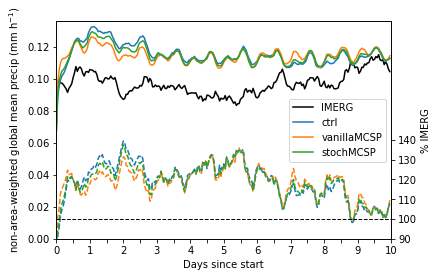

In [9]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(range(len(imerg.time)), imerg_ts, c='k', label='IMERG')
for expt in EXPTS:
    pflux_ts = expt_pflux[expt].mean(dim=['ens_mem', 'latitude', 'longitude'])
    l, = ax.plot(range(len(pflux_ts.time)), pflux_ts, label=expt)
    ax2.plot(range(len(pflux_ts.time)), pflux_ts.values / imerg_ts.values * 100, c=l.get_color(), ls='--', label=expt)
ax.set_xlabel('Days since start')
ax.set_ylabel('non-area-weighted global mean precip (mm h$^{-1}$)')
ax2.set_ylabel('% IMERG')
ax.legend(loc='center right')
ntime = len(imerg_ts)
times_half_days_hours = np.arange(0, ntime + 1, 12)
times_days = [int(v) for v in times_half_days_hours / 24]
times_days[1::2] = [''] * len(times_days[1::2])
ax.set_xticks(times_half_days_hours, times_days)
ax.set_xlim((0, ntime))
ax.set_ylim((0, None))
ax2.set_ylim((90, 200))
ax2.set_yticks(np.arange(90, 141, 10))
ax2.axhline(y=100, ls='--', lw=1, c='k')


In [10]:
def rmse(a1, a2):
    return np.sqrt(np.mean((a1 - a2)**2))

In [11]:
aspect = 1.43  # mean aspect ratio of cells over the tropics.
nsigma = 3
sel_tropics = {'latitude': slice(-30, 30)}
sigmas = [0, 1, 2, 4]
# dx / dy.

In [12]:
imerg_filtered = []
imerg_tropics = imerg.sel(**sel_tropics)

for sigma in sigmas:
    print(sigma)
    imerg_filtered_values = ndimage.gaussian_filter(imerg.sel(**sel_tropics), (0, aspect * sigma, sigma))
    da_imerg_filtered = imerg_tropics.copy()
    da_imerg_filtered.values = imerg_filtered_values
    imerg_filtered.append(da_imerg_filtered)
imerg_filtered = xr.concat(imerg_filtered, dim=pd.Index(sigmas, name='sigma'))
clear_output()

In [13]:
filtered_expt_pflux = {}

for expt in EXPTS:
    print(expt)
    pflux_tropics = expt_pflux[expt].sel(**sel_tropics)
    #print(da_pflux_filtered)
    
    pflux_filtered = []
    for sigma in sigmas:
        da_pflux_filtered = pflux_tropics.copy()

        print(sigma)
        for i in range(nens):
            if sigma != 0:    
                da_pflux_filtered.values[i] = ndimage.gaussian_filter(da_pflux_filtered.values[i], (0, aspect * sigma, sigma))
        pflux_filtered.append(da_pflux_filtered)
    pflux_filtered = xr.concat(pflux_filtered, dim=pd.Index(sigmas, name='sigma'))
            
    filtered_expt_pflux[expt] = pflux_filtered
#clear_output()

ctrl
0
1
2
4
vanillaMCSP
0
1
2
4
stochMCSP
0
1
2
4


In [14]:
np.abs(pflux_filtered.sel(sigma=0).values - pflux_tropics.values).max()

0.0

In [15]:
colors = ['#FFFFFF', '#0000FF', '#6495ED', '#7FFFD4', '#66CDAA', '#32CD32', '#ADFF2F', '#FFFF99', '#FFD700', '#FFA500', '#FF4500', '#800080']
# Create a custom colormap
cmap = mcolors.ListedColormap(colors)

0


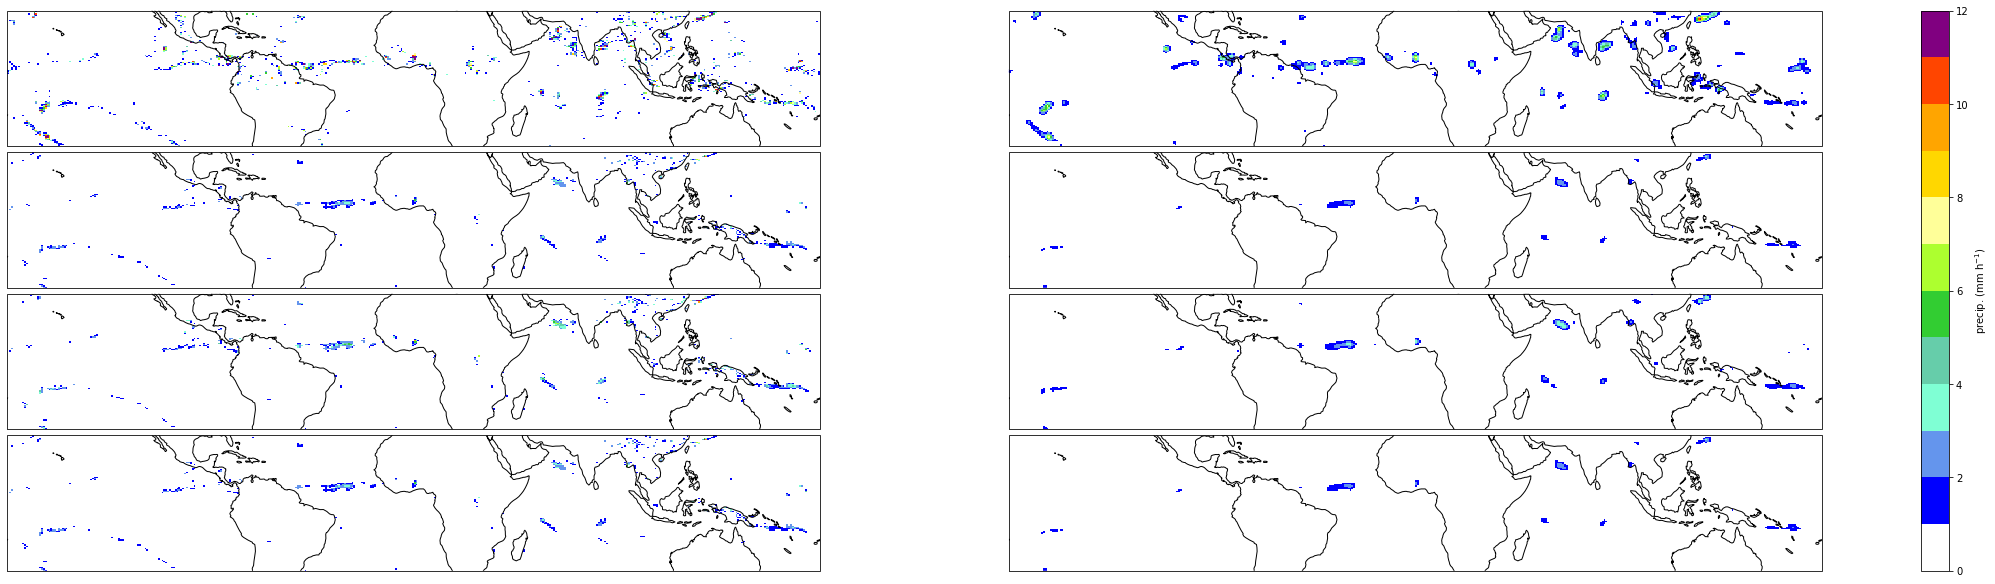

In [16]:
# %%capture
# %%script false --no-raise-error

# Set up the figure, the axis, and the plot element we want to animate
fig, axes = plt.subplots(4, 2, subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
fig.set_size_inches(30, 8)

# Update function for the animation
def plot_imerg_expts_sigmas(frame):
    print(frame)
    for ax in axes.flatten():
        ax.cla()
        ax.coastlines()
        ax.set_ylim((-30, 30))

    time = pd.Timestamp(filtered_expt_pflux['ctrl'].time[frame].values.item())
    for axrow, data in zip(
        axes, 
        [imerg_filtered] + [filtered_expt_pflux[expt].sel(ens_mem=0) for expt in EXPTS]
    ):
        for ax, sigma in zip(axrow, [0, 1]):
            im = ax.pcolormesh(data.longitude, data.latitude, data.sel(sigma=sigma)[frame], vmin=0, vmax=12, cmap=cmap)
    return im

im = plot_imerg_expts_sigmas(0)
plt.colorbar(im, ax=axes, label='precip. (mm h$^{-1}$)') 

In [17]:
filtered_expt_pflux['stochMCSP']

<xarray.DataArray 'precipitation_flux' (sigma: 4, ens_mem: 10, time: 240,
                                        latitude: 108, longitude: 432)>
array([[[[[3.10103986e-02, 2.14695378e-04, 1.22083575e-02, ...,
           1.85788386e-02, 4.82072464e-05, 5.68055722e-04],
          [1.66809303e-04, 2.93388846e-03, 3.89944110e-03, ...,
           1.82830337e-02, 2.30395943e-02, 2.68448144e-02],
          [3.95842217e-05, 2.13638749e-02, 3.24424982e-05, ...,
           1.30119389e-02, 1.95822548e-02, 5.31025726e-05],
          ...,
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         [[3.77704650e-02, 7.14298047e-04, 8.10317788e-03, ...,
           4.39509265e-02, 6.38197316e-03, 1.29948518e-07],
          [1.80284567e-02, 9.69067868e-03, 3.90137313e-03, ...,
           1.57634746e-02, 2.77027080e-04, 3.56630348e-02],
          [2.14507780e-03, 1.54258367e-02, 5.21816673e-06, ...,
           1.23750512e-02, 1.81899499e-02, 9.26499924e-05],
...
           3.07579030e-04, 2.18609232e-04, 1.77449576e-04],
          [2.32384500e-05, 2.57845950e-05, 3.03996749e-05, ...,
           3.20139719e-04, 2.26900665e-04, 1.83803277e-04],
          [2.22068829e-05, 2.46289874e-05, 2.90148801e-05, ...,
           3.26630077e-04, 2.31171609e-04, 1.87067053e-04]],

         [[3.66813433e-03, 3.58819729e-03, 3.43939196e-03, ...,
           1.69203873e-03, 1.57332025e-03, 1.51438406e-03],
          [3.69471754e-03, 3.61454301e-03, 3.46538308e-03, ...,
           1.74550898e-03, 1.62420329e-03, 1.56411936e-03],
          [3.74554843e-03, 3.66503908e-03, 3.51544493e-03, ...,
           1.84838800e-03, 1.72199716e-03, 1.65967003e-03],
          ...,
          [3.65382512e-05, 4.15118666e-05, 5.13152918e-05, ...,
           2.83997448e-04, 1.74299072e-04, 1.24464350e-04],
          [3.19027386e-05, 3.63417894e-05, 4.51201704e-05, ...,
           2.97644787e-04, 1.82484233e-04, 1.30165150e-04],
          [2.95538066e-05, 3.37189194e-05, 4.19712524e-05, ...,
           3.04706162e-04, 1.86715435e-04, 1.33109002e-04]]]]],
      dtype=float32)
Coordinates:
  * latitude   (latitude) float32 -29.72 -29.17 -28.61 ... 28.61 29.17 29.72
  * longitude  (longitude) float32 0.4167 1.25 2.083 2.917 ... 357.9 358.7 359.6
  * time       (time) datetime64[ns] 2020-07-01T04:00:00 ... 2020-07-11T03:00:00
  * ens_mem    (ens_mem) int64 0 1 2 3 4 5 6 7 8 9
  * sigma      (sigma) int64 0 1 2 4
Attributes:
    standard_name:        precipitation_flux
    units:                mm h-1
    um_stash_source:      m01s05i216
    grid_mapping:         latitude_longitude
    UM simulation:        u-dg135
    MCS:PRIME expt:       stochMCSP
    created by:           /home/users/mmuetz/projects/mcs_prime/ctrl/stoch_tr...
    calling file source:  import numpy as np\nimport pandas as pd\nimport xar...
    project repository:   https://github.com/markmuetz/MCS_PRIME
    remake version:       ['0', '6', '3', '0', 'beta']
    remake repository:    https://github.com/markmuetz/remake
    task:                 24f222d8c0 N216ExtractCombinePrecip(expt='stochMCSP')
    task doc:             Extract and combine precipitation at all times and ...
    created on:           2024-08-08 11:40:22.494223
    nodename:             sci4.jasmin.ac.uk
    hostname:             jasmin
    output path:          /gws/nopw/j04/mcs_prime/mmuetz/data/UM_sims/u-dg135...
    contact:              mark.muetzelfeldt@reading.ac.uk
    coordinates:          forecast_period_0 forecast_reference_time_0

In [18]:
expt_eRMSE = {}
ntime = len(imerg.time)
for expt in EXPTS:

    eRMSE = np.full((len(sigmas), nens, ntime), np.nan)
    pflux_filtered = filtered_expt_pflux[expt]

    for ens_idx in range(nens):
        for sigma_idx in range(len(sigmas)):
            print(expt, ens_idx, sigma_idx)
            for time_idx in range(ntime):
                eRMSE[sigma_idx, ens_idx, time_idx] = rmse(imerg_filtered[sigma_idx, time_idx], pflux_filtered[sigma_idx, ens_idx, time_idx])
            clear_output()
    da_eRMSE = xr.DataArray(
        eRMSE,
        coords={
            'sigma': pflux_filtered['sigma'],
            'ens_mem': pflux_filtered['ens_mem'],
            'time': pflux_filtered['time'],
        }
    )
    expt_eRMSE[expt] = da_eRMSE



In [19]:
expt_dRMSE = {}
for expt in EXPTS:

    dRMSE = np.full((len(sigmas), nens, nens, ntime), np.nan)
    pflux_filtered = filtered_expt_pflux[expt]
    
    for ens_idx1 in range(nens):
        for ens_idx2 in range(ens_idx1 + 1, nens):
            print(expt, ens_idx1, ens_idx2)
            for sigma_idx in range(len(sigmas)):
                for time_idx in range(ntime):
                    dRMSE[sigma_idx, ens_idx1, ens_idx2, time_idx] = rmse(
                        pflux_filtered[sigma_idx, ens_idx1, time_idx], 
                        pflux_filtered[sigma_idx, ens_idx2, time_idx]
                    )
    da_dRMSE = xr.DataArray(
        dRMSE,
        coords={
            'sigma': pflux_filtered['sigma'],
            'ens_mem1': pflux_filtered['ens_mem'].values,
            'ens_mem2': pflux_filtered['ens_mem'].values,
            'time': pflux_filtered['time'],
        }
    )
    expt_dRMSE[expt] = da_dRMSE

clear_output()

In [20]:
plot_sigmas = [0, 2, 4]
def plot_spread_skill_ts(smooth=False, xlim='full', show_skill_minus_spread=False):
    fig, axes = plt.subplots(1, len(plot_sigmas), sharex=True, layout='constrained')
    fig.set_size_inches(20, 6)
    cs = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for ax, sigma in zip(axes, plot_sigmas):
        if smooth:
            ax.set_title(f'$\sigma=${sigma} ({smooth} h smoothing)')
        else:
            ax.set_title(f'$\sigma=${sigma}')
        for i, expt in enumerate(EXPTS):
            # dRMSE_ts = np.nanmean(expt_dRMSE[expt], axis=(0, 1))
            # eRMSE_ts = np.nanmean(expt_eRMSE[expt], axis=0)
            dRMSE_ts = expt_dRMSE[expt].mean(dim=['ens_mem1', 'ens_mem2']).sel(sigma=sigma).values
            eRMSE_ts = expt_eRMSE[expt].mean(dim=['ens_mem']).sel(sigma=sigma).values
            if smooth:
                dRMSE_ts = np.convolve(dRMSE_ts, np.ones((smooth, )) / smooth, mode='same')
                eRMSE_ts = np.convolve(eRMSE_ts, np.ones((smooth, )) / smooth, mode='same')
            c = cs[i]
            ax.plot(eRMSE_ts, color=c, label=f'{expt} skill')
            ax.plot(dRMSE_ts, ls='--', color=c, label=f'{expt} spread')
            if show_skill_minus_spread:
                ax.plot(eRMSE_ts - dRMSE_ts, ls=':', color=c, label=f'{expt} skill - spread')
                ax.axhline(y=0, ls='-', lw=0.5, color='k')
    
        times_half_days_hours = np.arange(0, ntime + 1, 12)
        times_days = [int(v) for v in times_half_days_hours / 24]
        times_days[1::2] = [''] * len(times_days[1::2])
        ax.set_xticks(times_half_days_hours, times_days)
        ax.set_xlim((0, ntime))
    axes[0].set_ylabel('RMSE (mm h$^{-1}$)')
    if xlim != 'full':
        ax.set_xlim(xlim)
    if smooth and xlim == 'full':
        ax.set_xlim((smooth, 240 - smooth))
    for ax in axes:
        ax.relim()
        if not show_skill_minus_spread:
            ax.set_ylim((0, None))
    if len(axes) % 2 == 1:
        midax = axes[len(axes) // 2]
        midax.legend(ncol=len(EXPTS))
        midax.set_xlabel('time (day)')
        ylim = midax.get_ylim()
        midax.set_ylim((ylim[0], ylim[1] * 1.2))
    else:
        axes[-1].legend(ncol=len(EXPTS))
        for ax in axes.flatten():
            ax.set_xlabel('time (day)')
            


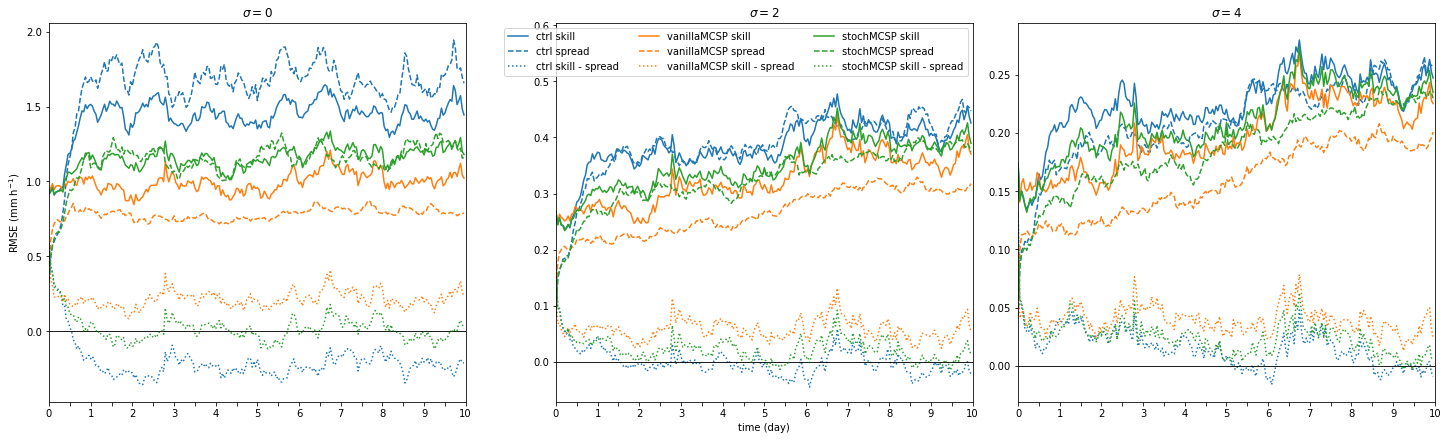

In [21]:
plot_spread_skill_ts(smooth=False, show_skill_minus_spread=True)

# Remarks

From email to Bob:

It is identical to the previous figures you saw over the first 20 h. It shows the skill, spread, and (new) skill - spread at the bottom for the 3 expts. Skill is defined by eRMSE, and spread is defined by dRMSE, and this is over the tropics (30S-30N) only. sigma=0 is no spatial smoothing, sigma=2 is 2x grid length smoothing, and sigma=4 is 4x grid length smoothing (taking into account aspect ratio grid cells).

Remarks:

* for sigma=0:
    * vanillaMCSP consistently has the lowest RMSE/highest skill. It is underdispersed. (todo: explain)
    * stochMCSP has slightly higher RMSE/lower skill than vanillaMCSP, and is well dispersed. (makes sense it's got higher spread)
    * ctrl has the highest spread and lowest skill, and is overdispersed.
    * all 3 expts seems to saturate after 2-3 days.
* for sigma=2, 4:
    * the expts don't seem to saturate until day 8 (why such a big change in behaviour?)
    * ctrl and stochMCSP better dispersed (sigma=2, less so for =4)
    * vanillaMCSP still underdispersed
    * might be a jump in skill/spread at around day 5?

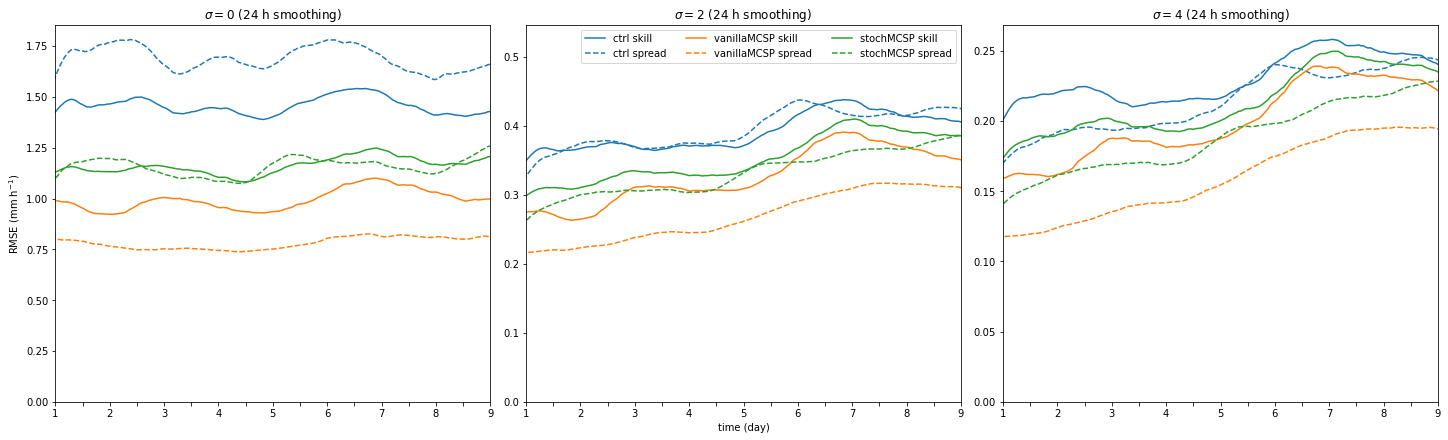

In [22]:
plot_spread_skill_ts(smooth=24)

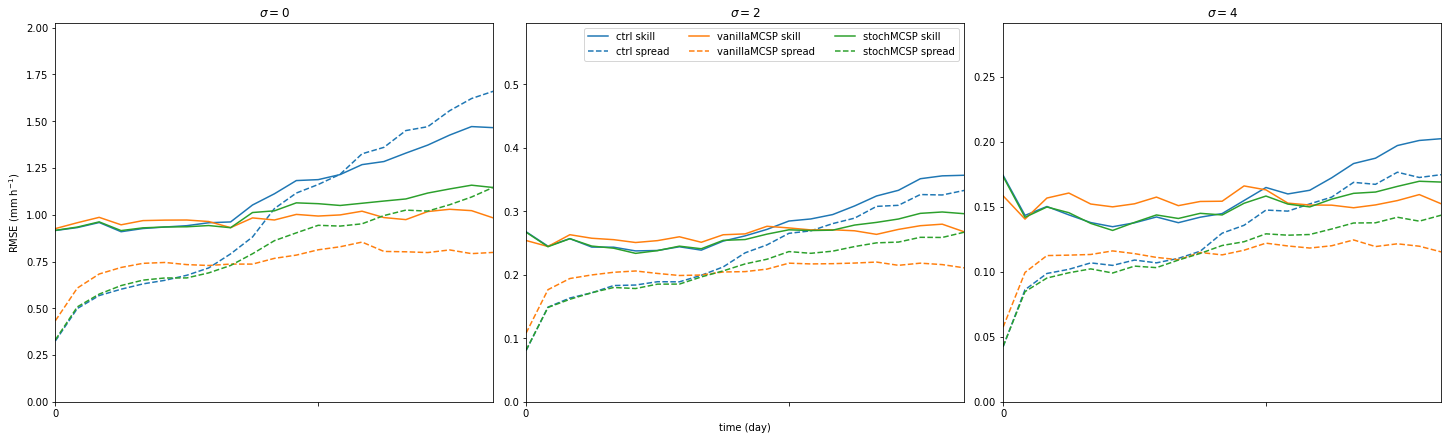

In [23]:
plot_spread_skill_ts(xlim=(0, 20))

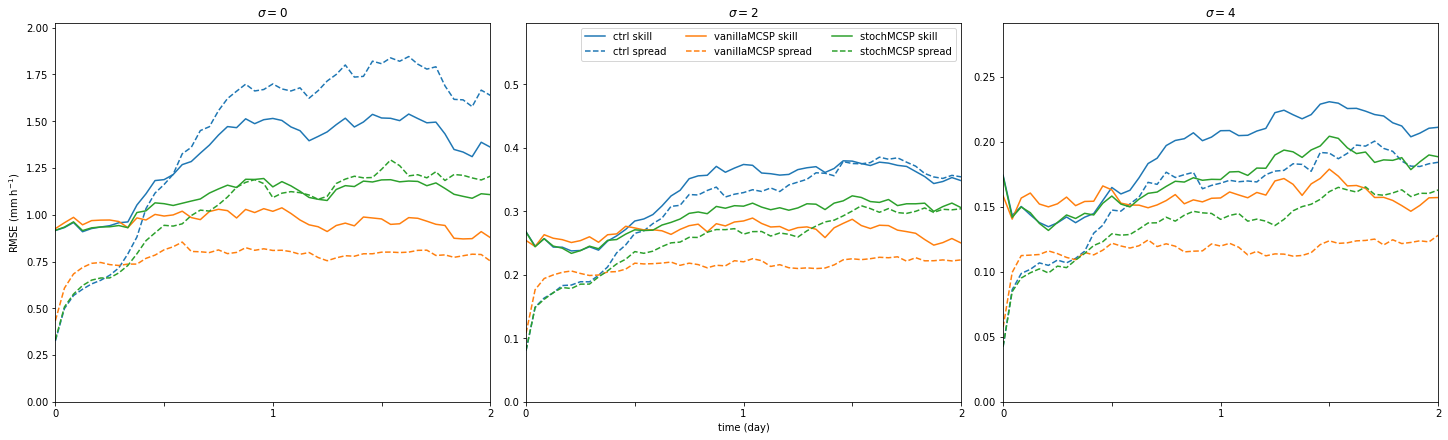

In [24]:
plot_spread_skill_ts(xlim=(0, 48))